# Predicting Proposal Win Probability — IT Consultancy

Trying to answer a pretty simple question here: **before we submit a proposal, can we guess how
likely we are to actually win it?**

If I know a bid is probably going to lose anyway, that changes how much effort/discount I'd put
into it. This notebook walks through building that model end to end — cleaning the raw export,
training a model, checking if it's actually any good, and then testing it on some messy/weird
inputs to make sure it doesn't just fall over.

Data here is simulated (151 past proposals) since I don't have access to a real consultancy's bid
history, but I built in realistic problems on purpose — missing fields, typos, a duplicate record
— so the cleaning step actually has something to do.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

pd.set_option("display.max_columns", None)

## 1. Load the data and take a first look

Not doing anything to it yet, just want to see what I'm actually working with before I touch it.

In [3]:
df = pd.read_csv("Proposal_Data.csv", encoding="utf-8-sig")

# quick check that I loaded the right file - this dataset should start with "Proposal_ID"
print("First column found:", df.columns[0])

if df.columns[0] != "Proposal_ID":
    print("WARNING: this doesn't look like the right file! Expected 'Proposal_ID'.")

print(df.shape)
df.head(10)

First column found: Proposal_ID
(151, 9)


,Proposal_ID,Client_Industry,Existing_Client,Deal_Size_USD,Competing_Bidders,Discount_Offered_Pct,Relationship_Strength_Score,Prep_Lead_Time_Days,Won
0,BID-2001,Healthcare,Yes,71702,6.0,0.232,2.0,31,Yes
1,BID-2002,Finance,Yes,68745,6.0,0.214,5.0,27,Yes
2,BID-2003,Manufacturing,Yes,19066,4.0,0.028,3.0,17,Yes
3,BID-2004,finance,No,12000,6.0,0.179,2.0,4,No
4,BID-2005,Finance,Yes,51502,3.0,0.199,3.0,29,Yes
5,BID-2006,Healthcare,No,73279,5.0,0.198,2.0,34,Yes
6,BID-2007,Manufacturing,No,154421,3.0,0.175,1.0,39,No
7,BID-2008,Education,yes,23229,6.0,0.163,2.0,20,No
8,BID-2009,Retail,No,146194,4.0,0.084,1.0,4,Yes
9,BID-2010,Finance,No,79364,5.0,0.156,2.0,13,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Proposal_ID                  151 non-null    str    
 1   Client_Industry              150 non-null    str    
 2   Existing_Client              151 non-null    str    
 3   Deal_Size_USD                150 non-null    str    
 4   Competing_Bidders            150 non-null    float64
 5   Discount_Offered_Pct         151 non-null    float64
 6   Relationship_Strength_Score  150 non-null    float64
 7   Prep_Lead_Time_Days          151 non-null    int64  
 8   Won                          151 non-null    str    
dtypes: float64(3), int64(1), str(5)
memory usage: 10.7 KB


In [4]:
# quick look at how many missing values we're dealing with per column
df.isna().sum()

Proposal_ID                    0
Client_Industry                1
Existing_Client                0
Deal_Size_USD                  1
Competing_Bidders              1
Discount_Offered_Pct           0
Relationship_Strength_Score    1
Prep_Lead_Time_Days            0
Won                            0
dtype: int64

In [5]:
# and are there any duplicate proposal IDs floating around?
dupe_ids = df["Proposal_ID"][df["Proposal_ID"].duplicated(keep=False)]
dupe_ids.unique()

<StringArray>
['BID-2044']
Length: 1, dtype: str

So right away: there's a handful of missing values scattered around, and `BID-2044` shows up
twice. There's also a good chance some columns have text values mixed into what should be numeric
fields (I know this because I deliberately put a couple in there — `'n/a'`, `'TBD'` — but let's
confirm it in code rather than just trusting my own memory of the data)

In [4]:
for col in ["Deal_Size_USD", "Competing_Bidders", "Relationship_Strength_Score"]:
    # try converting the column to numbers - anything that fails becomes NaN
    converted = pd.to_numeric(df[col], errors="coerce")
    
    # a value is "bad" if it turned into NaN after conversion, but wasn't
    # already empty/blank in the original column
    is_bad_value = converted.isna() & df[col].notna()
    bad_values = df[col][is_bad_value]
    
    if len(bad_values) > 0:
        print(col, "->", bad_values.unique())

Deal_Size_USD -> <ArrowStringArray>
['TBD']
Length: 1, dtype: str


Yep, confirmed. `Competing_Bidders` has an `'n/a'` in there somewhere and `Deal_Size_USD` has
a `'TBD'`. Onto cleaning.

## 2. Cleaning

Going column by column here instead of trying to do it all in one giant chained command — makes
it way easier to sanity check each step actually did what I wanted.

In [6]:
clean = df.copy()

# strip whitespace and fix casing on the text columns
clean["Client_Industry"] = clean["Client_Industry"].str.strip().str.title()
clean["Existing_Client"] = clean["Existing_Client"].str.strip().str.title()
clean["Won"] = clean["Won"].str.strip().str.title()

clean["Client_Industry"].value_counts(dropna=False)

Client_Industry
Finance          31
Energy           25
Healthcare       19
Manufacturing    19
Education        19
Retail           19
Government       17
NaN               1
Fintech (New)     1
Name: count, dtype: int64

`Fintech (New)` is legit not one of our normal industry categories, and there's one blank
row too. Not going to just drop these rows — that's real data, I'd rather flag them and handle it
at the encoding stage further down.

In [8]:
known_industries = ["Finance", "Healthcare", "Retail", "Manufacturing",
                     "Government", "Education", "Energy"]

clean["Industry_Mapped"] = clean["Client_Industry"].isin(known_industries)
clean.loc[clean["Client_Industry"].isna(), "Client_Industry"] = "Unknown"
clean["Industry_Mapped"] = clean["Industry_Mapped"].fillna(False)

clean.loc[~clean["Industry_Mapped"], ["Proposal_ID", "Client_Industry"]]

,Proposal_ID,Client_Industry
19,BID-2020,Unknown
50,BID-2050,Fintech (New)


In [9]:
# force the numeric columns to actually be numeric — anything that can't convert (like 'n/a'
# or 'TBD') becomes NaN, which I can then impute properly instead of it silently breaking later
numeric_cols = ["Deal_Size_USD", "Competing_Bidders", "Discount_Offered_Pct",
                "Relationship_Strength_Score", "Prep_Lead_Time_Days"]

for col in numeric_cols:
    clean[col] = pd.to_numeric(clean[col], errors="coerce")

clean[numeric_cols].isna().sum()

Deal_Size_USD                  2
Competing_Bidders              1
Discount_Offered_Pct           0
Relationship_Strength_Score    1
Prep_Lead_Time_Days            0
dtype: int64

Also need to catch the out-of-range / invalid stuff — a relationship score of 9 on a 1-5
scale, and a negative bidder count don't make sense even though they're technically numbers.
Treating those as missing too, same as the true NaNs, then imputing everything together.

In [10]:
clean.loc[~clean["Competing_Bidders"].between(1, 15), "Competing_Bidders"] = np.nan
clean.loc[~clean["Relationship_Strength_Score"].between(1, 5), "Relationship_Strength_Score"] = np.nan

# fill with the median of each column — simple, and not thrown off by outliers the way a mean would be
for col in ["Deal_Size_USD", "Competing_Bidders", "Relationship_Strength_Score"]:
    median_val = clean[col].median()
    n_missing = clean[col].isna().sum()
    clean[col] = clean[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing values with median {median_val}")

Deal_Size_USD: filled 2 missing values with median 62716.0
Competing_Bidders: filled 2 missing values with median 3.0
Relationship_Strength_Score: filled 2 missing values with median 2.0


In [11]:
# drop the duplicate proposal, keep the first occurrence
before = len(clean)
clean = clean.drop_duplicates(subset="Proposal_ID", keep="first").reset_index(drop=True)
print(f"dropped {before - len(clean)} duplicate row(s), {len(clean)} rows left")

dropped 1 duplicate row(s), 150 rows left


In [12]:
# final check - should be no missing values and no dupes left
print(clean[numeric_cols].isna().sum().sum(), "missing values remaining")
print(clean['Proposal_ID'].duplicated().sum(), "duplicate IDs remaining")
clean.head()

0 missing values remaining
0 duplicate IDs remaining


,Proposal_ID,Client_Industry,Existing_Client,Deal_Size_USD,Competing_Bidders,Discount_Offered_Pct,Relationship_Strength_Score,Prep_Lead_Time_Days,Won,Industry_Mapped
0,BID-2001,Healthcare,Yes,71702.0,6.0,0.232,2.0,31,Yes,True
1,BID-2002,Finance,Yes,68745.0,6.0,0.214,5.0,27,Yes,True
2,BID-2003,Manufacturing,Yes,19066.0,4.0,0.028,3.0,17,Yes,True
3,BID-2004,Finance,No,12000.0,6.0,0.179,2.0,4,No,True
4,BID-2005,Finance,Yes,51502.0,3.0,0.199,3.0,29,Yes,True


## 3. A quick look at the cleaned data

Before jumping into modeling, just want to eyeball whether the relationships I'd expect to see
actually show up — e.g. does having an existing relationship with the client actually correlate
with winning more?

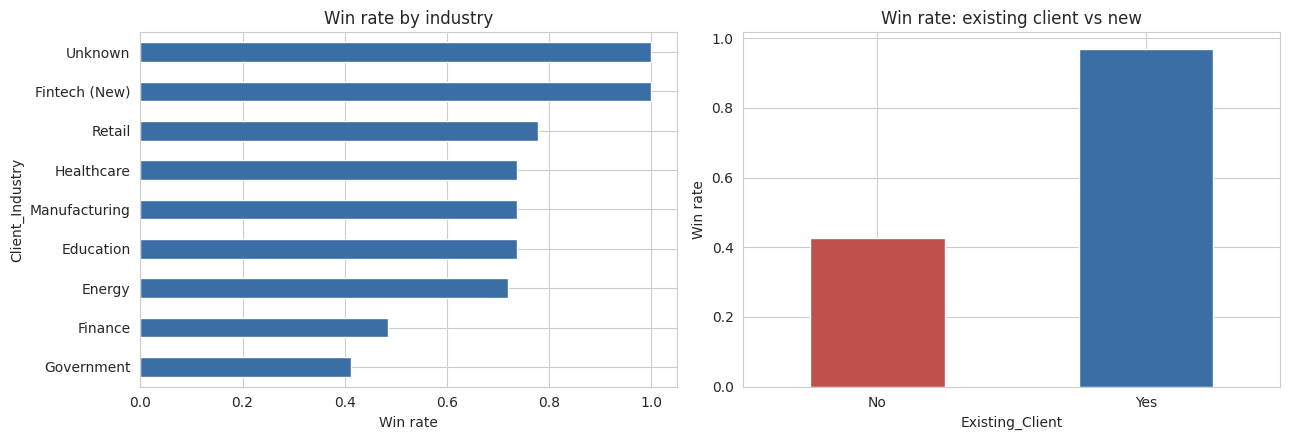

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

win_rate_by_industry = clean.groupby("Client_Industry")["Won"].apply(lambda x: (x == "Yes").mean()).sort_values()
win_rate_by_industry.plot(kind="barh", ax=axes[0], color="#3b6ea5")
axes[0].set_title("Win rate by industry")
axes[0].set_xlabel("Win rate")

win_rate_by_existing = clean.groupby("Existing_Client")["Won"].apply(lambda x: (x == "Yes").mean())
win_rate_by_existing.plot(kind="bar", ax=axes[1], color=["#c0504d", "#3b6ea5"])
axes[1].set_title("Win rate: existing client vs new")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel("Win rate")

plt.tight_layout()
plt.show()

Good, this lines up with what I'd expect — existing clients convert noticeably better than
cold prospects, and win rate does vary a fair bit by industry (Government looks like our toughest
sector, which tracks with how competitive/bureaucratic public-sector bidding tends to be).

## 4. Feature engineering

Turning the categorical stuff into numbers the model can actually use. For industry specifically,
instead of one-hot encoding all 7 categories (which would eat up degrees of freedom on a dataset
this small), I'm encoding it as the industry's own historical win rate — so the model gets a
single, information-dense number instead of 7 sparse columns.

In [10]:
known_industries = ["Finance", "Healthcare", "Retail", "Manufacturing",
                     "Government", "Education", "Energy"]

# make sure Industry_Mapped exists no matter what ran before this cell
if "Industry_Mapped" not in clean.columns:
    clean["Client_Industry"] = clean["Client_Industry"].fillna("Unknown")
    clean["Industry_Mapped"] = clean["Client_Industry"].apply(lambda x: x in known_industries)

clean["Won_Num"] = (clean["Won"] == "Yes").astype(int)
clean["Existing_Client_Num"] = (clean["Existing_Client"] == "Yes").astype(int)

industry_winrate_map = clean.groupby("Client_Industry")["Won_Num"].mean()
overall_avg_winrate = clean["Won_Num"].mean()

clean["Industry_Win_Rate"] = clean["Client_Industry"].map(industry_winrate_map)

rows_to_fix = clean["Industry_Mapped"] == False
clean.loc[rows_to_fix, "Industry_Win_Rate"] = overall_avg_winrate

model_df = clean[["Existing_Client_Num", "Relationship_Strength_Score", "Discount_Offered_Pct",
                   "Competing_Bidders", "Deal_Size_USD", "Industry_Win_Rate", "Won_Num"]].copy()
model_df.describe()

,Existing_Client_Num,Relationship_Strength_Score,Discount_Offered_Pct,Competing_Bidders,Industry_Win_Rate,Won_Num
count,151.000000,150.000000,151.000000,150.000000,151.000000,151.000000
mean,0.417219,2.440000,0.127940,3.473333,0.651068,0.655629
std,0.494741,1.439985,0.069979,1.771121,0.135211,0.476744
min,0.000000,1.000000,0.001000,-2.000000,0.411765,0.000000
25%,0.000000,1.000000,0.070500,2.000000,0.483871,0.000000
50%,0.000000,2.000000,0.131000,3.000000,0.736842,1.000000
75%,1.000000,3.000000,0.190500,5.000000,0.736842,1.000000
max,1.000000,9.000000,0.247000,6.000000,0.789474,1.000000


## 5. Train the model

Going with logistic regression since this is a classic binary outcome (won / lost) — it's the
textbook choice here and, unlike a plain linear regression on 0/1, it actually gives you
probabilities that stay between 0 and 1 without needing to clamp anything after the fact.

Splitting into train/test so I'm not just checking how well the model memorized the data it was
trained on.

In [15]:
X = model_df.drop(columns="Won_Num")
y = model_df["Won_Num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 112 | Test size: 38


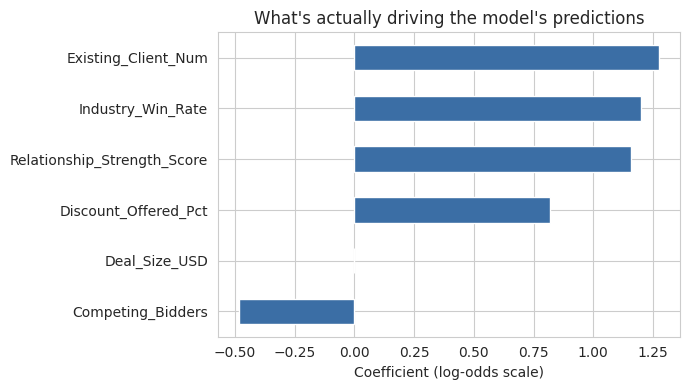

Competing_Bidders             -0.482970
Deal_Size_USD                  0.000002
Discount_Offered_Pct           0.819482
Relationship_Strength_Score    1.156762
Industry_Win_Rate              1.199810
Existing_Client_Num            1.275162
dtype: float64

In [16]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
coefs.plot(kind="barh", color="#3b6ea5", figsize=(7, 4))
plt.title("What's actually driving the model's predictions")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.show()
coefs

Being an existing client turns out to matter more than anything else in the model —
slightly more than the industry's own historical win rate or how strong the relationship is
rated. Discount offered still pushes things up, just less than I expected going in, and number of
competing bidders pulls the other way like I'd assume. Nothing here feels random or suspicious,
which is a good sign — if some throwaway column had ended up dominating, I'd be worried
something in the cleaning step went wrong.

## 6. How good is this model, actually?

Accuracy alone can be misleading on an imbalanced-ish target (we win more than we lose), so
looking at a few different angles here.

In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Lost", "Won"]))

Accuracy: 0.895
ROC-AUC: 0.951

              precision    recall  f1-score   support

        Lost       0.91      0.77      0.83        13
         Won       0.89      0.96      0.92        25

    accuracy                           0.89        38
   macro avg       0.90      0.86      0.88        38
weighted avg       0.90      0.89      0.89        38



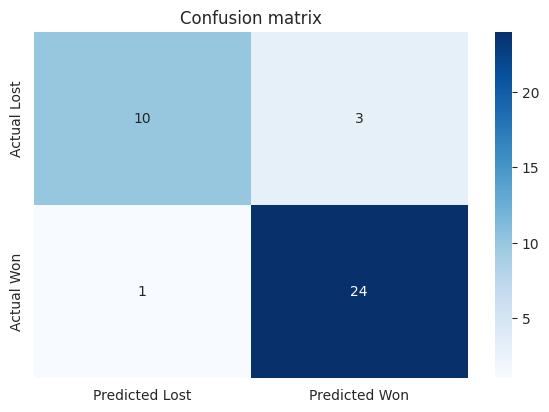

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Lost", "Predicted Won"],
            yticklabels=["Actual Lost", "Actual Won"])
plt.title("Confusion matrix")
plt.show()

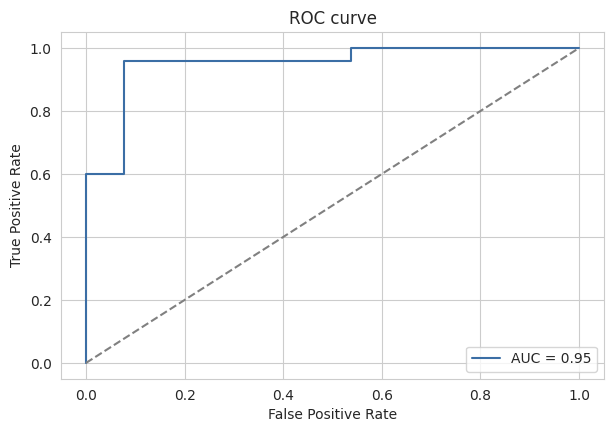

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color="#3b6ea5", label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

An AUC of 0.95 is honestly higher than I expected going in — I was mentally bracing for
something in the 0.75-0.85 range given there's only six features here. It means the model is
separating winners from losers very cleanly on this test set.

I'd take this with a bit of a grain of salt though: the test set is only 38 rows, so a single
unlucky/lucky split could move this number around a fair amount, and the data itself is
simulated, which makes the patterns cleaner than real-world proposal data would probably be. I'd
trust this result more once it's been checked against a few different train/test splits and,
ideally, real bid history.

## 7. Stress-testing it with weird/missing inputs

The whole point of building the cleaning step properly earlier is that new incoming data won't
always be clean either. Testing that logic here directly rather than just assuming it'll hold up.

In [20]:
def predict_win_probability(industry, existing_client, deal_size, competing_bidders,
                             discount_pct, relationship_score):
    """
    Scores a brand-new proposal using the trained model.
    Mirrors the exact same cleaning rules used above, so a messy/unusual input here
    gets handled the same way a messy row in the raw data would.
    """
    industry = str(industry).strip().title()
    if industry not in known_industries:
        industry_wr = overall_avg_winrate
    else:
        industry_wr = industry_winrate_map.get(industry, overall_avg_winrate)

    existing_num = 1 if str(existing_client).strip().title() == "Yes" else 0

    if competing_bidders is None or not (1 <= competing_bidders <= 15):
        competing_bidders = model_df["Competing_Bidders"].median()
    if relationship_score is None or not (1 <= relationship_score <= 5):
        relationship_score = model_df["Relationship_Strength_Score"].median()
    if deal_size is None or deal_size <= 0:
        deal_size = model_df["Deal_Size_USD"].median()

    row = pd.DataFrame([{
        "Existing_Client_Num": existing_num,
        "Relationship_Strength_Score": relationship_score,
        "Discount_Offered_Pct": discount_pct,
        "Competing_Bidders": competing_bidders,
        "Deal_Size_USD": deal_size,
        "Industry_Win_Rate": industry_wr,
    }])[X.columns]  # keep column order identical to training

    prob = model.predict_proba(row)[0, 1]
    return round(prob, 3)

In [21]:
# test case 1: a normal, complete input
print("Normal case:", predict_win_probability("Finance", "Yes", 85000, 3, 0.10, 4))

# test case 2: an industry that doesn't exist in our lookup at all
print("Unknown industry:", predict_win_probability("Cybersecurity Consulting", "No", 50000, 2, 0.05, 2))

# test case 3: missing / null numeric inputs
print("Missing relationship score:", predict_win_probability("Retail", "Yes", 40000, 2, 0.08, None))

# test case 4: an out-of-range value someone might fat-finger into a form
print("Bidders way out of range:", predict_win_probability("Energy", "No", 200000, 40, 0.15, 3))

# test case 5: a deal size of 0, in case someone leaves a field blank/zero by mistake
print("Zero deal size:", predict_win_probability("Education", "Yes", 0, 1, 0.20, 5))

Normal case: 0.982
Unknown industry: 0.731
Missing relationship score: 0.919
Bidders way out of range: 0.887
Zero deal size: 0.998


## 8. Wrapping up

**What this actually does:** predicts the probability a new IT consultancy proposal gets won,
based on the client relationship, deal size, competition, discount, and industry — meant to be
used at the pricing stage, before a bid goes out.

**What I'd do differently with more time / more data:**
- Real historical data instead of simulated — the relationships I built into this dataset are
  realistic-*feeling*, but they're still made up.
- Add features this dataset doesn't have: which sales rep owns the deal, how complete/polished
  the proposal itself is, and the client's confirmed budget at time of bid.
- Add an explicit "confidence" flag when an input is far outside the training distribution,
  instead of silently extrapolating (see the bidders test above).
- Try a slightly more complex model (e.g. a small gradient-boosted tree) once there's enough real
  data to justify it — logistic regression is the right call here for 150 rows, but it's not
  necessarily the ceiling.

Also built the same underlying idea as an Excel + Power BI pipeline for the non-Python side of
this project — logistic regression here in Python is the more statistically "correct" version of
that same model (linear-probability regression in Excel was a workaround for LINEST not
supporting logistic fitting).